## 🏏 IPL 2025 — Batting & Bowling Performance Analysis

# 📦 Step 1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

batting_colors = ['#ff6b35', '#f7931e', '#ffd700', '#ff4500', '#ff8c00',
                  '#dc143c', '#ff69b4', '#ff1493', '#c0392b', '#e74c3c']

bowling_colors = ['#4a90d9', '#6c5ce7', '#a29bfe', '#74b9ff', '#0984e3',
                  '#2d3436', '#636e72', '#b2bec3', '#81ecec', '#00cec9']

team_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#1abc9c',
               '#3498db', '#9b59b6', '#e91e63', '#ff5722', '#795548']

print("Gradient colors ready!")


Gradient colors ready!


# 📂 Step 2: Load the Dataset

In [4]:
batters = pd.read_csv('IPL2025Batters.csv')
bowlers = pd.read_csv('IPL2025Bowlers.csv')

# 🔍 Step 3: Basic Data Exploration

In [5]:
# Batters Datase
batters.head()
batters.info()
batters.describe()
batters.isnull().sum()
batters.duplicated().sum()

# Bowlers Dataset
bowlers.head()
bowlers.info()
bowlers.describe()
bowlers.isnull().sum()
bowlers.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Player Name  156 non-null    object 
 1   Team         156 non-null    object 
 2   Runs         156 non-null    int64  
 3   Matches      156 non-null    int64  
 4   Inn          156 non-null    int64  
 5   No           156 non-null    int64  
 6   HS           156 non-null    object 
 7   AVG          156 non-null    object 
 8   BF           156 non-null    int64  
 9   SR           156 non-null    float64
 10  100s         156 non-null    int64  
 11  50s          156 non-null    int64  
 12  4s           156 non-null    int64  
 13  6s           156 non-null    int64  
dtypes: float64(1), int64(9), object(4)
memory usage: 17.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------  

np.int64(0)

# 🧹 Step 4: Data Cleaning

In [6]:
# Remove Duplicate Rows
batters.drop_duplicates(inplace=True)
bowlers.drop_duplicates(inplace=True)

# Fill Missing Values
batters.fillna(0, inplace=True)
bowlers.fillna(0, inplace=True)


# ⚙️ Step 5: Feature Engineering

Creating new calculated columns to better measure player performance:

In [7]:
# Batters Features
batters['Runs_per_Match'] = batters['Runs'] / batters['Matches']

batters['Boundary_Runs'] = (
    batters['4s'] * 4 +
    batters['6s'] * 6
)

batters['Boundary_Percentage'] = (
    batters['Boundary_Runs'] / batters['Runs']
) * 100

# Bowlers Features
bowlers['Wickets_per_Match'] = (
    bowlers['WKT'] / bowlers['MAT']
)

bowlers['Bowling_Impact'] = (
    bowlers['WKT'] / bowlers['ECO']
)


# 📊 Step 6: Exploratory Data Analysis (EDA)

## 🏆 Chart 1 — Top 10 Run Scorers

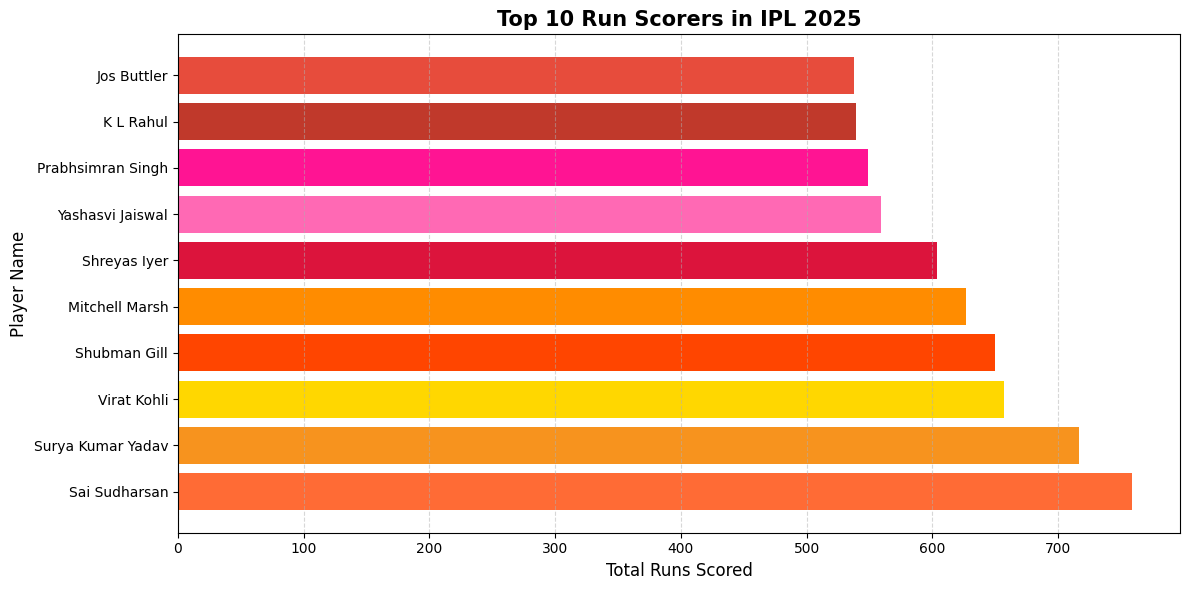

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

top_runs = batters.sort_values(by='Runs', ascending=False).head(10)

bars = ax.barh(top_runs['Player Name'], top_runs['Runs'], color=batting_colors)

ax.set_title('Top 10 Run Scorers in IPL 2025', fontsize=15, fontweight='bold')
ax.set_xlabel('Total Runs Scored', fontsize=12)
ax.set_ylabel('Player Name', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### 💡 Insight
- Reveals the **Orange Cap** contenders of IPL 2025.
- Players with the most runs are consistent match-winners.
- Helps identify batsmen carrying their teams.

## 🎯 Chart 2 — Top 10 Wicket Takers

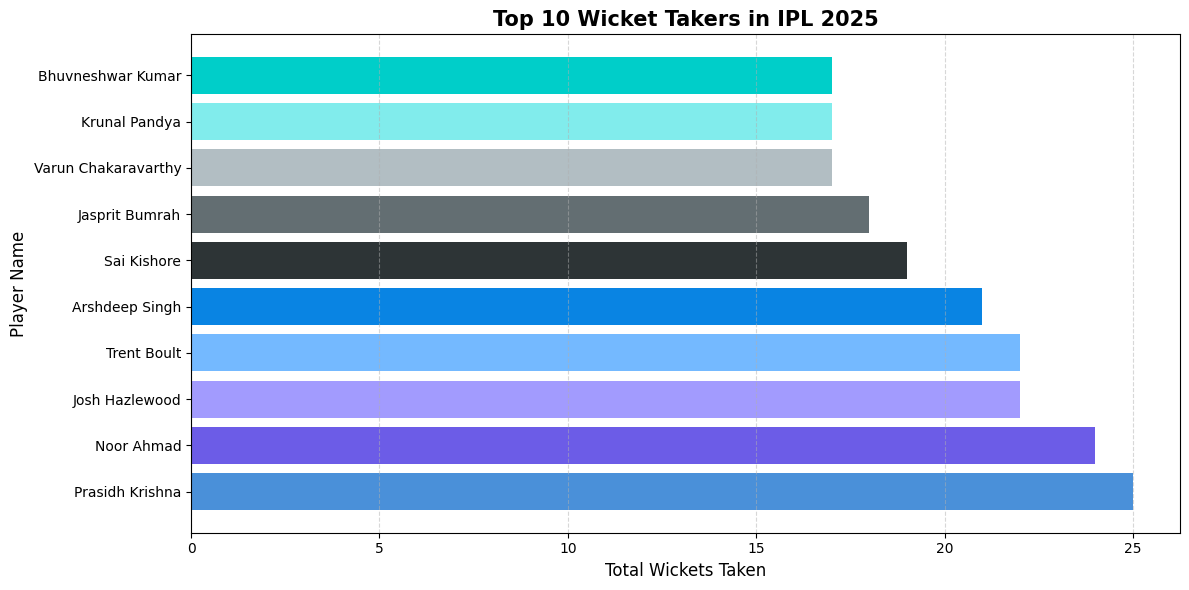

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

top_wickets = bowlers.sort_values(by='WKT', ascending=False).head(10)

bars = ax.barh(top_wickets['Player Name'], top_wickets['WKT'], color=bowling_colors)

ax.set_title('Top 10 Wicket Takers in IPL 2025', fontsize=15, fontweight='bold')
ax.set_xlabel('Total Wickets Taken', fontsize=12)
ax.set_ylabel('Player Name', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### 💡 Insight
- Highlights the **Purple Cap** contenders of IPL 2025.
- Top bowlers often decide outcomes in close matches.
- Consistent wicket-takers are key match-winners.

## 🏟️ Chart 3 — Team-wise Total Runs

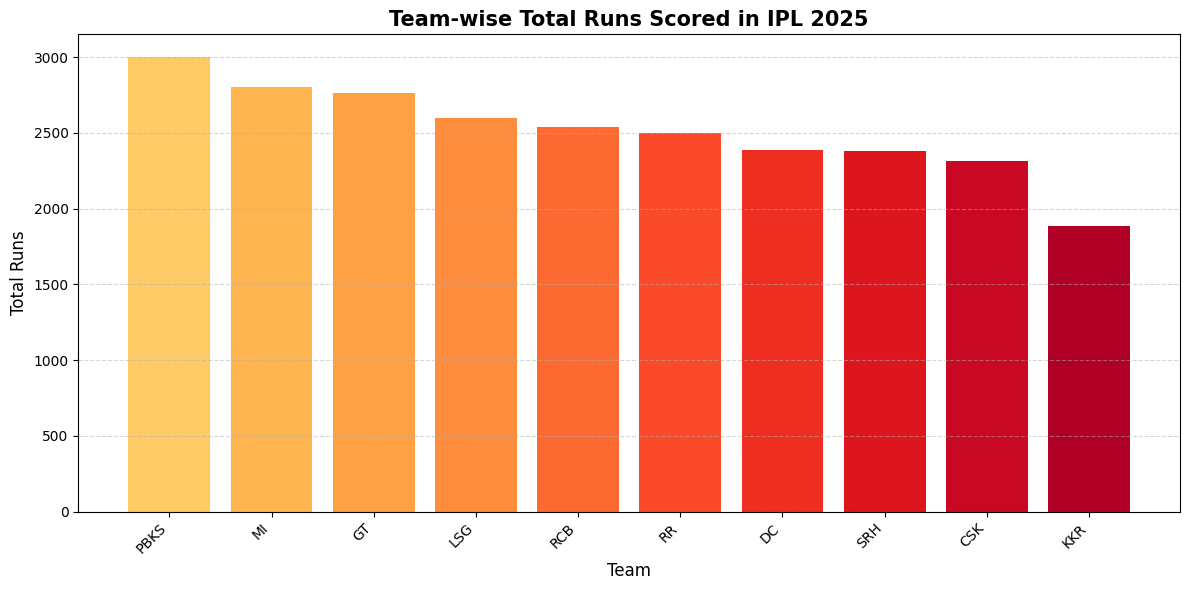

In [10]:
team_runs = batters.groupby('Team')['Runs'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(team_runs)))
bars = ax.bar(team_runs.index, team_runs.values, color=colors)

ax.set_title('Team-wise Total Runs Scored in IPL 2025', fontsize=15, fontweight='bold')
ax.set_xlabel('Team', fontsize=12)
ax.set_ylabel('Total Runs', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### 💡 Insight
- Teams with higher total runs tend to have stronger batting lineups.
- A strong batting unit often means better Win/Loss records.

## 🎳 Chart 4 — Team-wise Total Wickets

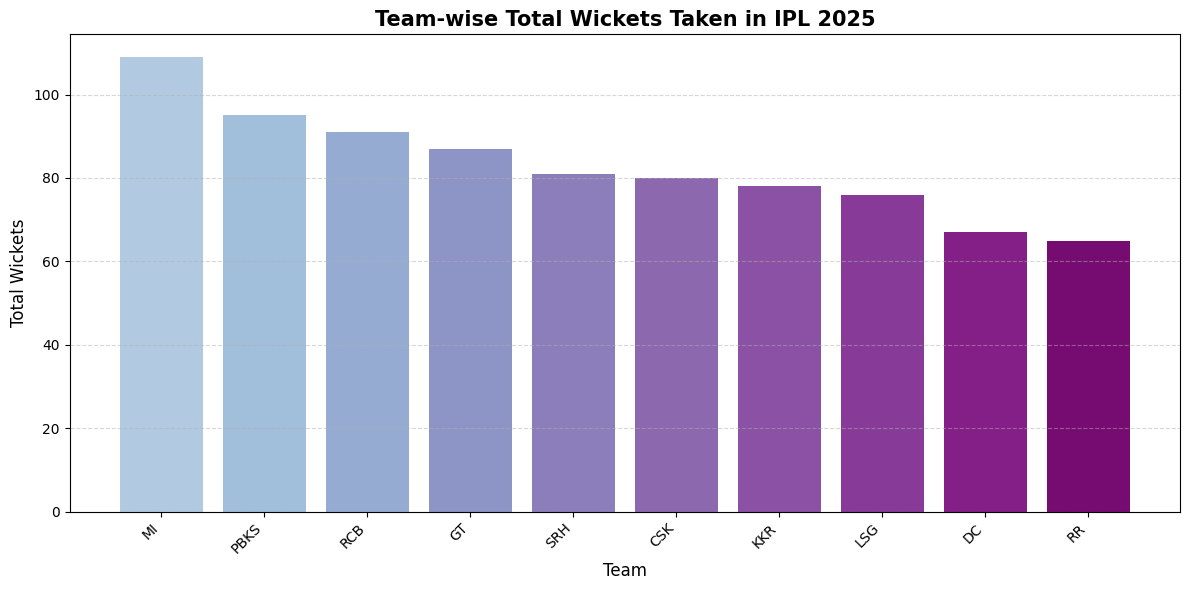

In [11]:
team_wickets = bowlers.groupby('Team')['WKT'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.BuPu(np.linspace(0.3, 0.9, len(team_wickets)))
bars = ax.bar(team_wickets.index, team_wickets.values, color=colors)

ax.set_title('Team-wise Total Wickets Taken in IPL 2025', fontsize=15, fontweight='bold')
ax.set_xlabel('Team', fontsize=12)
ax.set_ylabel('Total Wickets', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### 💡 Insight
- Teams with more total wickets have a stronger bowling attack.
- Bowling depth is critical in T20 tournaments like IPL.

## 📈 Chart 5 — Strike Rate Distribution

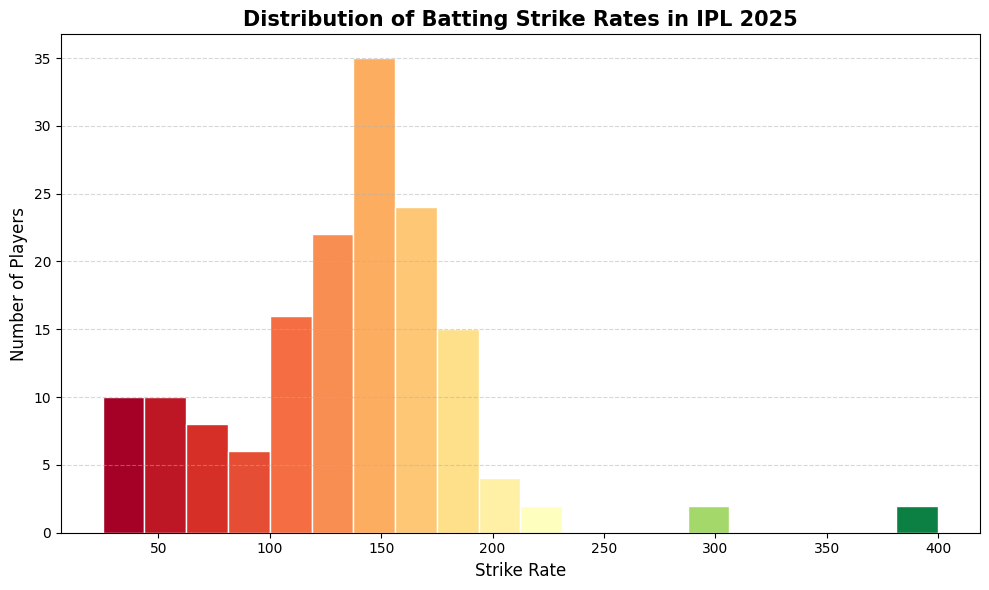

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

n, bins, patches = ax.hist(batters['SR'], bins=20, edgecolor='white')

# Color each bar using a gradient
for i, patch in enumerate(patches):
    color = plt.cm.RdYlGn(i / len(patches))
    patch.set_facecolor(color)

ax.set_title('Distribution of Batting Strike Rates in IPL 2025', fontsize=15, fontweight='bold')
ax.set_xlabel('Strike Rate', fontsize=12)
ax.set_ylabel('Number of Players', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### 💡 Insight
- Most batsmen in IPL operate between 120–160 strike rate.
- Very few players maintain extremely high or very low strike rates.
- Distribution reveals the general batting aggression level in IPL 2025.

## 🔵 Chart 6 — Batting Average vs Strike Rate

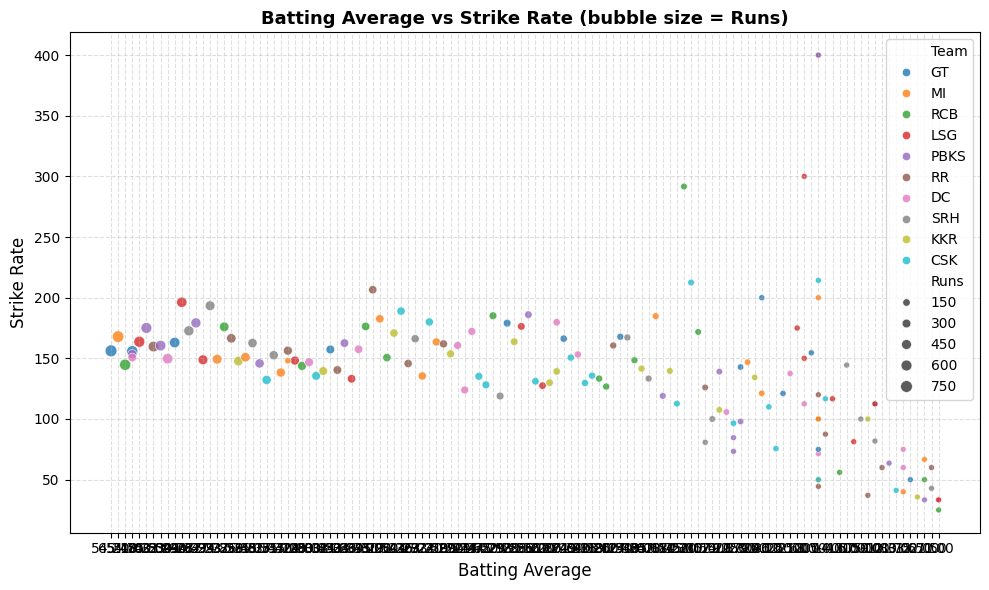

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    x='AVG',
    y='SR',
    size='Runs',
    hue='Team',
    data=batters,
    palette='tab10',
    alpha=0.8,
    edgecolor='white',
    linewidth=0.5
)

ax.set_title('Batting Average vs Strike Rate (bubble size = Runs)', fontsize=13, fontweight='bold')
ax.set_xlabel('Batting Average', fontsize=12)
ax.set_ylabel('Strike Rate', fontsize=12)
ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


### 💡 Insight
- The **top-right quadrant** (high avg + high SR) contains the most elite batsmen.
- Bubble size shows total runs — bigger bubbles = more impactful players.
- Most players trade off between average and strike rate.

## 💥 Chart 7 — Top Boundary Hitters

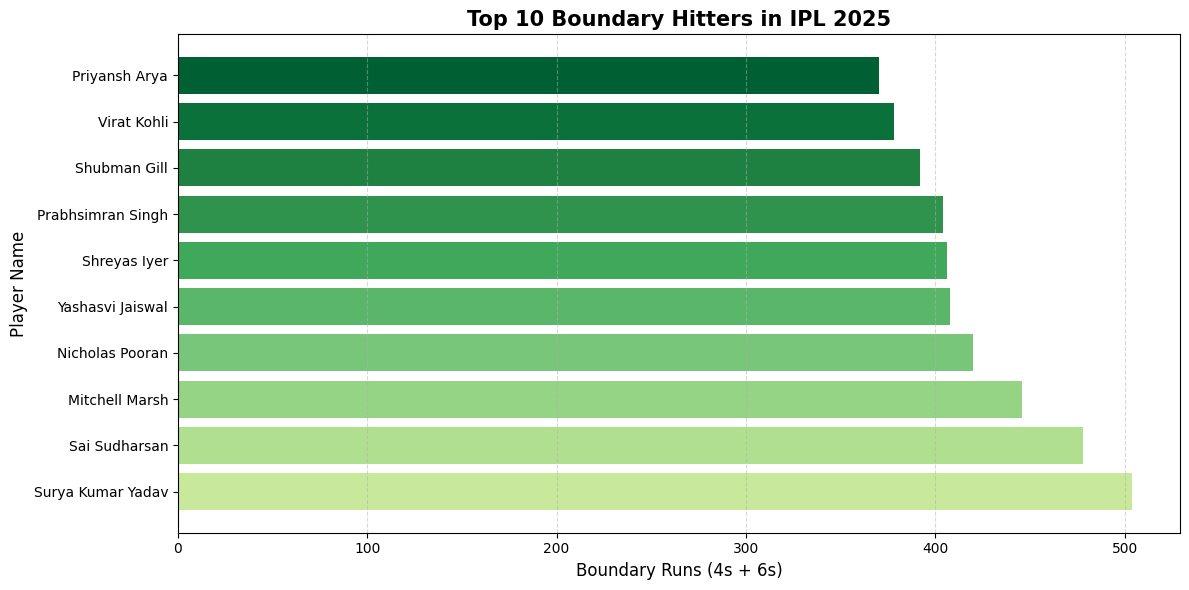

In [14]:
boundary_players = batters.sort_values(by='Boundary_Runs', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.YlGn(np.linspace(0.3, 0.9, len(boundary_players)))
bars = ax.barh(boundary_players['Player Name'], boundary_players['Boundary_Runs'], color=colors)

ax.set_title('Top 10 Boundary Hitters in IPL 2025', fontsize=15, fontweight='bold')
ax.set_xlabel('Boundary Runs (4s + 6s)', fontsize=12)
ax.set_ylabel('Player Name', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### 💡 Insight
- Boundary hitters (big 4s and 6s) are the most explosive batsmen.
- High boundary runs strongly correlate with high strike rates.
- These players are crucial in the death overs.

## 📉 Chart 8 — Economy Rate Distribution

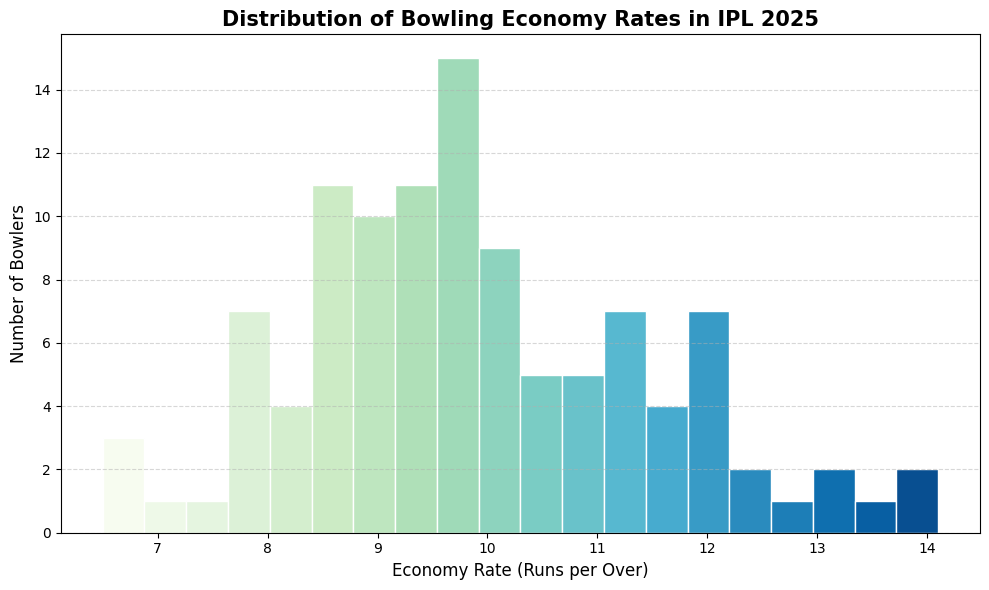

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

n, bins, patches = ax.hist(bowlers['ECO'], bins=20, edgecolor='white')

# Color each bar using a gradient
for i, patch in enumerate(patches):
    color = plt.cm.GnBu(i / len(patches))
    patch.set_facecolor(color)

ax.set_title('Distribution of Bowling Economy Rates in IPL 2025', fontsize=15, fontweight='bold')
ax.set_xlabel('Economy Rate (Runs per Over)', fontsize=12)
ax.set_ylabel('Number of Bowlers', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### 💡 Insight
- Most bowlers operate between an economy of 7–10 in T20 cricket.
- Bowlers with economy below 7 are considered very disciplined.
- High-economy bowlers are often only used for wicket-taking purposes.

## 🔴 Chart 9 — Economy Rate vs Wickets

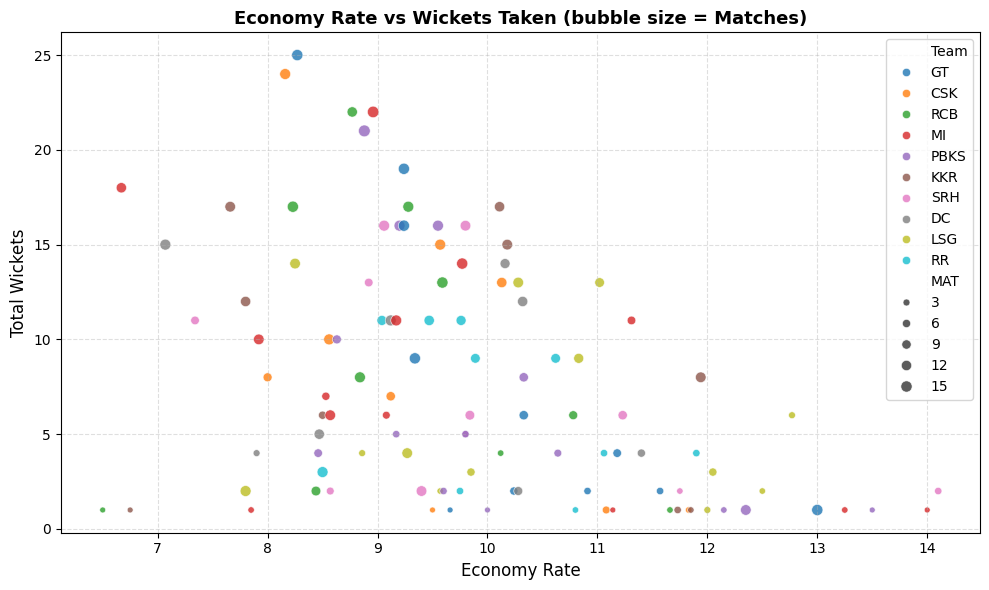

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    x='ECO',
    y='WKT',
    size='MAT',
    hue='Team',
    data=bowlers,
    palette='tab10',
    alpha=0.8,
    edgecolor='white',
    linewidth=0.5
)

ax.set_title('Economy Rate vs Wickets Taken (bubble size = Matches)', fontsize=13, fontweight='bold')
ax.set_xlabel('Economy Rate', fontsize=12)
ax.set_ylabel('Total Wickets', fontsize=12)
ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


### 💡 Insight
- The **ideal bowler** sits in the bottom-right: low economy + high wickets.
- Bubble size shows matches played — experience matters.
- Most bowlers must balance wicket-taking with conceding fewer runs.

## ⚡ Chart 10 — Team-wise Average Strike Rate

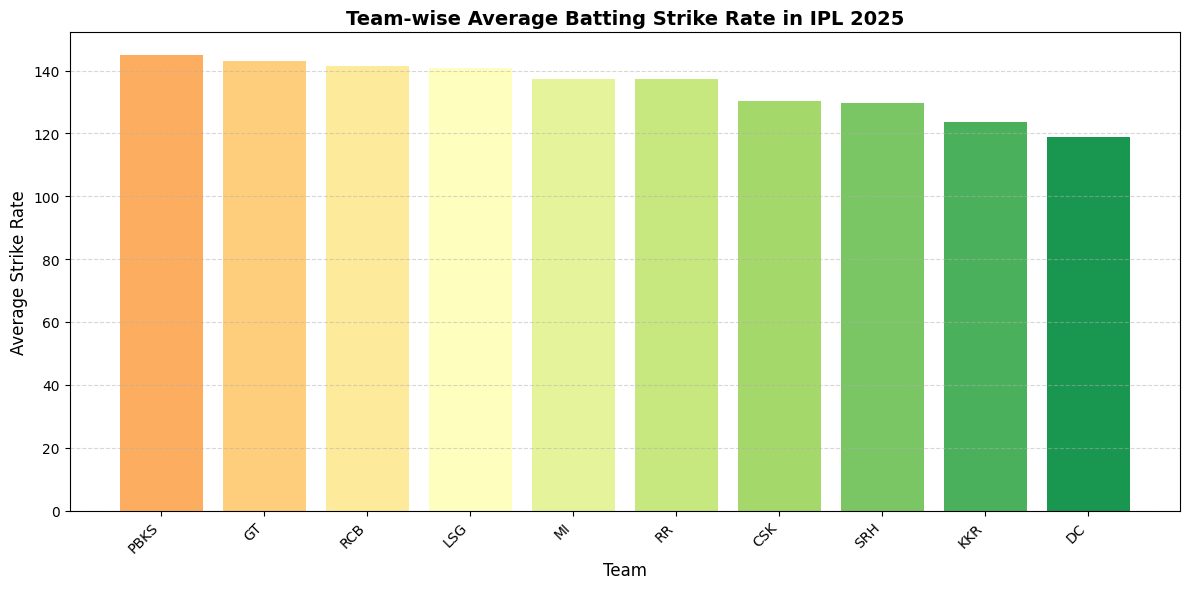

In [17]:
team_sr = batters.groupby('Team')['SR'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(team_sr)))
bars = ax.bar(team_sr.index, team_sr.values, color=colors)

ax.set_title('Team-wise Average Batting Strike Rate in IPL 2025', fontsize=14, fontweight='bold')
ax.set_xlabel('Team', fontsize=12)
ax.set_ylabel('Average Strike Rate', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### 💡 Insight
- Teams with higher average strike rates are more aggressive and risky.
- Aggressive batting can lead to big wins but also quick collapses.

## 🎯 Chart 11 — Team-wise Average Economy

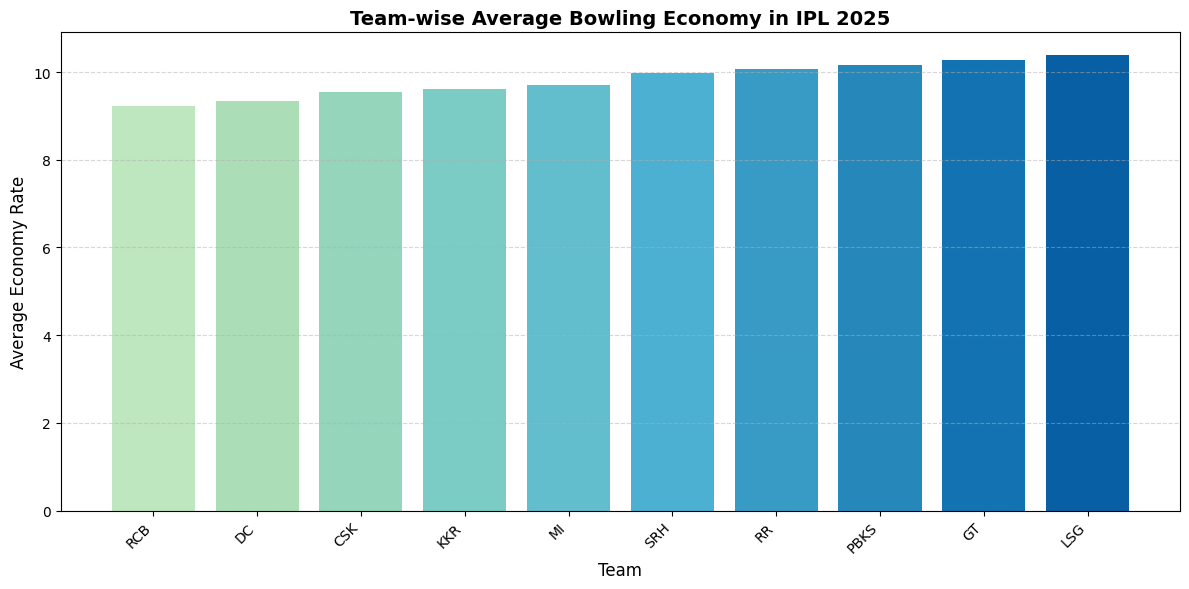

In [18]:
team_economy = bowlers.groupby('Team')['ECO'].mean().sort_values()

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.GnBu(np.linspace(0.3, 0.9, len(team_economy)))
bars = ax.bar(team_economy.index, team_economy.values, color=colors)

ax.set_title('Team-wise Average Bowling Economy in IPL 2025', fontsize=14, fontweight='bold')
ax.set_xlabel('Team', fontsize=12)
ax.set_ylabel('Average Economy Rate', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### 💡 Insight
- Teams with lower average economy have better bowling discipline.
- Consistent low economy across the team is a sign of a well-drilled bowling unit.

## 🔥 Chart 12 — Correlation Heatmap (Batting Statistics)

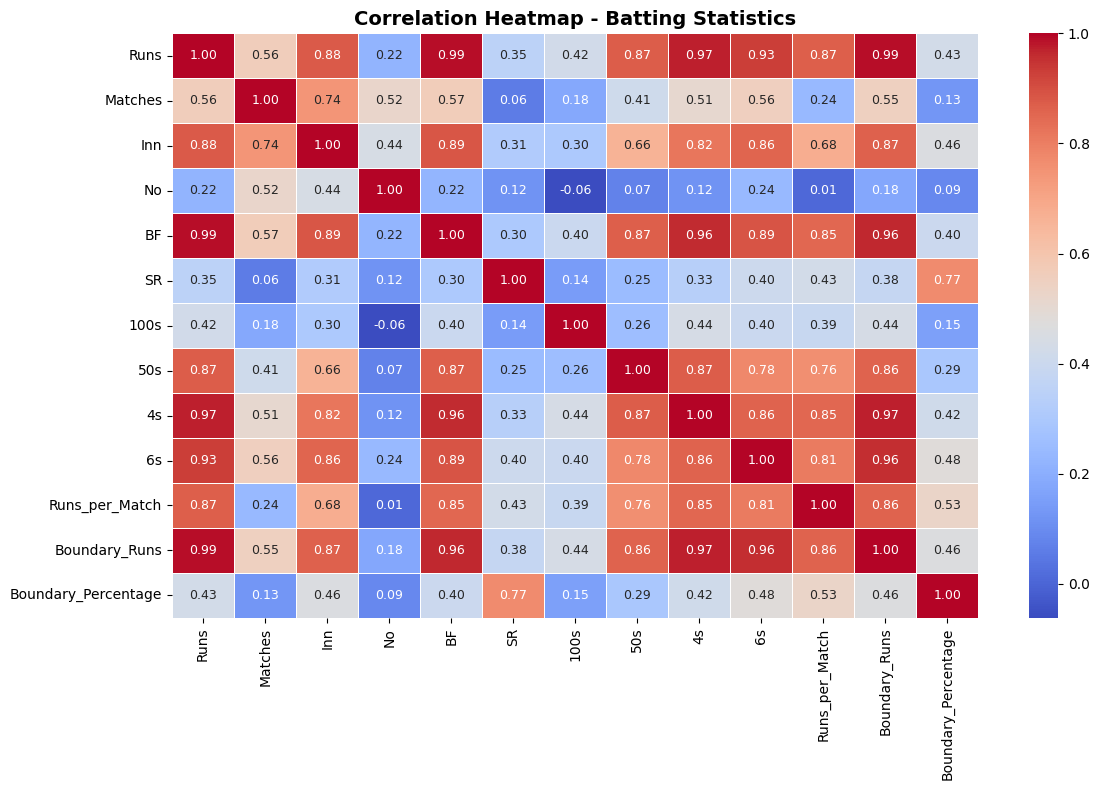

In [19]:
plt.figure(figsize=(12, 8))

numeric_batters = batters.select_dtypes(include=np.number)

sns.heatmap(
    numeric_batters.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={'size': 9}
)

plt.title('Correlation Heatmap - Batting Statistics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 💡 Insight
- Strong positive correlation between **Runs** and **Boundary Runs** — power hitting drives scoring.
- **Strike Rate** and **Boundary %** are highly correlated.
- **Average** and **Runs** together tell the best story of a batsman's quality.

## 🌊 Chart 13 — Correlation Heatmap (Bowling Statistics)

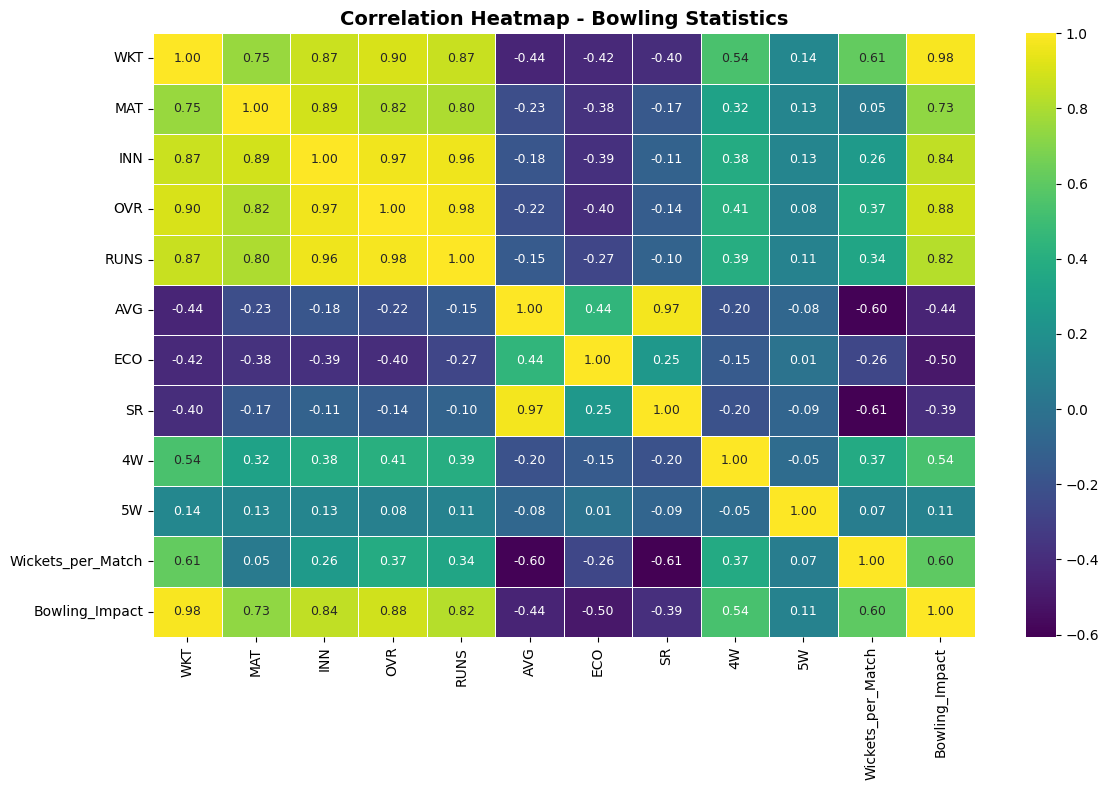

In [20]:
plt.figure(figsize=(12, 8))

numeric_bowlers = bowlers.select_dtypes(include=np.number)

sns.heatmap(
    numeric_bowlers.corr(),
    annot=True,
    fmt='.2f',
    cmap='viridis',
    linewidths=0.5,
    annot_kws={'size': 9}
)

plt.title('Correlation Heatmap - Bowling Statistics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 💡 Insight
- **WKT** (wickets) and **Bowling Impact** are strongly correlated.
- Economy and wickets taken have a complex relationship — great bowlers manage both.
- Matches played strongly correlates with total wickets (experience matters).

# 🏁 Key Takeaways

## 🏏 Batting Insights

- The top run scorers dominate the Orange Cap race and carry their teams throughout the season.
- Teams with higher average strike rates are more aggressive but also more susceptible to collapses.
- Boundary percentage is strongly linked to strike rate — power hitters score faster.
- Elite batsmen maintain both a high average and a high strike rate simultaneously.

---

## 🎳 Bowling Insights

- The most impactful bowlers combine low economy with a high wicket count.
- Some teams rely heavily on bowling discipline to keep opposition totals low.
- Wickets per match is a more reliable metric than total wickets to judge true bowling quality.

---

# ✅ Conclusion

This EDA project analysed IPL 2025 batting and bowling data using:

- **Data Cleaning** — removed duplicates, filled missing values
- **Feature Engineering** — created Runs per Match, Boundary %, Bowling Impact, etc.
- **Statistical Analysis** — distributions, correlations, and group comparisons

The analysis helps identify the best batsmen, the most impactful bowlers, the strongest teams, the most aggressive batting units, and the most economical bowling attacks.
